In [ ]:
# ── PHASE 3 BLOCK 1 ──────────────────────────────
# Title: Environment Setup + Folder Structure
# Purpose: Confirm GPU, create folders, install dependencies

import os
import torch

# ── Mount Drive ───────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/securescope-ai'

# ── Create folder structure ───────────────────────
folders = [
    f'{PROJECT}/data',
    f'{PROJECT}/models/saved/codebert_binary',
    f'{PROJECT}/models/saved/codebert_type',
    f'{PROJECT}/notebooks',
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Ready: {folder}")

# ── Confirm data files exist ──────────────────────
print("\nChecking data files...")
train_path = f'{PROJECT}/data/PyCode_Vul_train.xlsx'
test_path  = f'{PROJECT}/data/PyCode_Vul_test.csv'

train_exists = os.path.exists(train_path)
test_exists  = os.path.exists(test_path)

print(f"  PyCode_Vul_train.xlsx: {'FOUND' if train_exists else 'MISSING — upload to Drive'}")
print(f"  PyCode_Vul_test.csv:   {'FOUND' if test_exists else 'MISSING — upload to Drive'}")

if not train_exists or not test_exists:
    raise FileNotFoundError("Upload missing data files to Drive before continuing.")

# ── GPU check ─────────────────────────────────────
print(f"\nPyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU")

# ── Install dependencies ──────────────────────────
print("\nInstalling Phase 3 dependencies...")
os.system("pip install transformers==4.40.0 peft==0.10.0 accelerate==0.29.0 datasets -q")

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

print("\nAll Phase 3 imports successful.")
print("Ready for CodeBERT fine-tuning.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready: /content/drive/MyDrive/securescope-ai/data
Ready: /content/drive/MyDrive/securescope-ai/models/saved/codebert_binary
Ready: /content/drive/MyDrive/securescope-ai/models/saved/codebert_type
Ready: /content/drive/MyDrive/securescope-ai/notebooks

Checking data files...
  PyCode_Vul_train.xlsx: FOUND
  PyCode_Vul_test.csv:   FOUND

PyTorch: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4

Installing Phase 3 dependencies...

All Phase 3 imports successful.
Ready for CodeBERT fine-tuning.


In [ ]:
import os

PROJECT = '/content/drive/MyDrive/securescope-ai'

folders = [
    f'{PROJECT}/data',
    f'{PROJECT}/models/saved/codebert_binary',
    f'{PROJECT}/models/saved/codebert_type',
    f'{PROJECT}/notebooks',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"Created: {folder}")

print("\nAll folders ready.")

Created: /content/drive/MyDrive/securescope-ai/data
Created: /content/drive/MyDrive/securescope-ai/models/saved/codebert_binary
Created: /content/drive/MyDrive/securescope-ai/models/saved/codebert_type
Created: /content/drive/MyDrive/securescope-ai/notebooks

All folders ready.


In [ ]:
# ── PHASE 3 BLOCK 2 ──────────────────────────────
# Title: Load and Inspect Datasets
# Purpose: Load PyCode Vul for CodeBERT binary model
#          Load VUDENC and inspect whether true vulnerability
#          type labels are available

import pandas as pd
import numpy as np
from datasets import load_dataset
from collections import Counter

PROJECT = '/content/drive/MyDrive/securescope-ai'

# ── Dataset 1: PyCode Vul Binary Classification ──
print("=" * 60)
print("DATASET 1: PyCode Vul (Binary Classification)")
print("=" * 60)

raw_train = pd.read_excel(f'{PROJECT}/data/PyCode_Vul_train.xlsx')
raw_test  = pd.read_csv(f'{PROJECT}/data/PyCode_Vul_test.csv')

# Correct code selection:
# vulnerable rows use vulnerable_function_source
# safe rows use patched_function_source
train_df = pd.DataFrame()
train_df['code'] = np.where(
    raw_train['label'] == 1,
    raw_train['vulnerable_function_source'],
    raw_train['patched_function_source']
)
train_df['label'] = raw_train['label'].astype(int)

# Test file already provides function_code + class
test_df = pd.DataFrame()
test_df['code'] = raw_test['function_code']
test_df['label'] = raw_test['class'].astype(int)

# Clean missing rows
before_train = len(train_df)
before_test = len(test_df)

train_df = train_df.dropna(subset=['code', 'label']).copy()
test_df = test_df.dropna(subset=['code', 'label']).copy()

train_df['code'] = train_df['code'].astype(str)
test_df['code'] = test_df['code'].astype(str)
train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

print(f"Train before cleaning: {before_train}")
print(f"Train after cleaning:  {len(train_df)}")
print(f"Test before cleaning:  {before_test}")
print(f"Test after cleaning:   {len(test_df)}")

print("\nTrain labels:")
print(train_df['label'].value_counts().sort_index())

print("\nTest labels:")
print(test_df['label'].value_counts().sort_index())

print("\nTrain label percentages:")
print((train_df['label'].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTest label percentages:")
print((test_df['label'].value_counts(normalize=True).sort_index() * 100).round(2))

print(f"\nAvg train code length (chars): {train_df['code'].str.len().mean():.0f}")
print(f"Max train code length (chars): {train_df['code'].str.len().max():.0f}")

print("\nDuplicate train code samples:", train_df.duplicated(subset=['code']).sum())
print("Duplicate test code samples:", test_df.duplicated(subset=['code']).sum())

overlap = set(train_df['code']).intersection(set(test_df['code']))
print("Exact train/test code overlap:", len(overlap))


# ── Dataset 2: VUDENC Inspection ─────────────────
print("\n" + "=" * 60)
print("DATASET 2: VUDENC (Inspection)")
print("=" * 60)

print("Loading VUDENC from HuggingFace...")
vudenc = load_dataset("DetectVul/Vudenc")

print(vudenc)
print(f"\nTrain: {len(vudenc['train'])} functions")
print(f"Test:  {len(vudenc['test'])} functions")

print("\nVUDENC train features:")
print(vudenc['train'].features)

print("\nVUDENC train columns:")
print(vudenc['train'].column_names)

print("\nExample 0 structure:")
ex = vudenc['train'][0]
for key, value in ex.items():
    print("=" * 80)
    print("KEY:", key)
    print("PYTHON TYPE:", type(value))

    if isinstance(value, list):
        print("LIST LENGTH:", len(value))
        print("FIRST 10 VALUES:", value[:10])
    else:
        print("VALUE:", value)

# Inspect line-level labels/types if present
if 'label' in vudenc['train'].column_names:
    vulnerable_function_count = 0
    vulnerable_line_count = 0
    type_counter = Counter()

    for ex in vudenc['train']:
        labels = ex.get('label', [])
        line_types = ex.get('type', [])

        if isinstance(labels, list):
            has_vuln = any(l == 1 for l in labels)
            vulnerable_line_count += sum(1 for l in labels if l == 1)

            if has_vuln:
                vulnerable_function_count += 1

            if isinstance(line_types, list):
                for t, l in zip(line_types, labels):
                    if l == 1:
                        type_counter[str(t)] += 1

    print("\nVUDENC line-level label summary:")
    print(f"Vulnerable functions: {vulnerable_function_count}")
    print(f"Safe functions:       {len(vudenc['train']) - vulnerable_function_count}")
    print(f"Vulnerable lines:     {vulnerable_line_count}")

    if type_counter:
        print("\nValues in `type` for vulnerable lines:")
        for t, c in sorted(type_counter.items(), key=lambda x: -x[1]):
            print(f"  {t:<30}: {c}")

# Search for original VUDENC vulnerability category names
print("\nSearching VUDENC fields for vulnerability category keywords...")

keywords = [
    "sql", "xss", "command", "xsrf", "csrf",
    "remote", "execution", "path", "redirect",
    "injection", "disclosure"
]

keyword_hits = {k: 0 for k in keywords}
field_hits = {}

for split in ["train", "test"]:
    for ex in vudenc[split]:
        for field, value in ex.items():
            values = value if isinstance(value, list) else [value]

            for item in values:
                text = str(item).lower()

                for keyword in keywords:
                    if keyword in text:
                        keyword_hits[keyword] += 1
                        field_hits.setdefault(field, set()).add(keyword)

print("\nKeyword hits:")
for keyword, count in keyword_hits.items():
    print(f"{keyword:<12}: {count}")

print("\nFields containing keyword hits:")
if field_hits:
    for field, found_keywords in field_hits.items():
        print(f"{field}: {sorted(found_keywords)}")
else:
    print("No vulnerability category keywords found in exposed fields.")

print("\nBlock 2 complete.")

DATASET 1: PyCode Vul (Binary Classification)
Train before cleaning: 14248
Train after cleaning:  14164
Test before cleaning:  3563
Test after cleaning:   3563

Train labels:
label
0    7918
1    6246
Name: count, dtype: int64

Test labels:
label
0    1962
1    1601
Name: count, dtype: int64

Train label percentages:
label
0    55.9
1    44.1
Name: proportion, dtype: float64

Test label percentages:
label
0    55.07
1    44.93
Name: proportion, dtype: float64

Avg train code length (chars): 2503
Max train code length (chars): 47984

Duplicate train code samples: 42
Duplicate test code samples: 0
Exact train/test code overlap: 91

DATASET 2: VUDENC (Inspection)
Loading VUDENC from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-4cfe5148f991ec(…):   0%|          | 0.00/5.66M [00:00<?, ?B/s]

data/test-00000-of-00001-7b79e04247817e1(…):   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3169 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['lines', 'raw_lines', 'label', 'type'],
        num_rows: 12672
    })
    test: Dataset({
        features: ['lines', 'raw_lines', 'label', 'type'],
        num_rows: 3169
    })
})

Train: 12672 functions
Test:  3169 functions

VUDENC train features:
{'lines': List(Value('string')), 'raw_lines': List(Value('string')), 'label': List(Value('int64')), 'type': List(Value('string'))}

VUDENC train columns:
['lines', 'raw_lines', 'label', 'type']

Example 0 structure:
KEY: lines
PYTHON TYPE: <class 'list'>
LIST LENGTH: 7
FIRST 10 VALUES: ['@integration_synonym_api...\n', 'FUNC_2(VAR_2)\n', "FUNC_3(VAR_2, 'VENIZIA', VAR_7='1')\n", "FUNC_3(VAR_2, 'VENEZIA', VAR_7='2')\n", "FUNC_3(VAR_2, 'VANSEA', VAR_7='3')\n", "FUNC_3(VAR_2, 'WENSO', VAR_7='4')\n", "FUNC_5(VAR_4, VAR_5, VAR_11='VENIZIA', VAR_10=[{'name': '----VENIZIA'}, {\n    'name': 'VENEZIA'}])\n"]
KEY: raw_lines
PYTHON TYPE: <class 'list'>
LIST LENGTH: 7
FIRST 10 VALUES: ['@integrati

In [ ]:
# ── PHASE 3 BLOCK 3 ──────────────────────────────
# Title: Clean PyCode Vul for CodeBERT Binary
# Purpose: Remove train/test leakage and duplicate train code,
#          then create train/validation split

from sklearn.model_selection import train_test_split

print("Before cleanup:")
print("Train rows:", len(train_df))
print("Holdout rows:", len(test_df))

# Remove exact train/test code overlap from training only
test_code_set = set(test_df['code'])
overlap_mask = train_df['code'].isin(test_code_set)

print("Train rows overlapping holdout:", overlap_mask.sum())

train_df_clean = train_df.loc[~overlap_mask].copy()

# Remove duplicate train code samples
dup_count = train_df_clean.duplicated(subset=['code']).sum()
print("Duplicate train code samples after overlap removal:", dup_count)

train_df_clean = train_df_clean.drop_duplicates(subset=['code']).copy()

print("\nAfter cleanup:")
print("Train rows:", len(train_df_clean))
print("Holdout rows:", len(test_df))

print("\nClean train distribution:")
print(train_df_clean['label'].value_counts().sort_index())

print("\nClean train percentages:")
print((train_df_clean['label'].value_counts(normalize=True).sort_index() * 100).round(2))

# Train/validation split from cleaned training only
train_split, val_split = train_test_split(
    train_df_clean,
    test_size=0.15,
    random_state=42,
    stratify=train_df_clean['label']
)

print("\nFinal Phase 3 split:")
print(f"Train:   {len(train_split)}")
print(f"Val:     {len(val_split)}")
print(f"Holdout: {len(test_df)}")

print("\nTrain distribution:")
print(train_split['label'].value_counts().sort_index())

print("\nVal distribution:")
print(val_split['label'].value_counts().sort_index())

print("\nHoldout distribution:")
print(test_df['label'].value_counts().sort_index())

print("Block 3 complete.")

Before cleanup:
Train rows: 14164
Holdout rows: 3563
Train rows overlapping holdout: 92
Duplicate train code samples after overlap removal: 41

After cleanup:
Train rows: 14031
Holdout rows: 3563

Clean train distribution:
label
0    7786
1    6245
Name: count, dtype: int64

Clean train percentages:
label
0    55.49
1    44.51
Name: proportion, dtype: float64

Final Phase 3 split:
Train:   11926
Val:     2105
Holdout: 3563

Train distribution:
label
0    6618
1    5308
Name: count, dtype: int64

Val distribution:
label
0    1168
1     937
Name: count, dtype: int64

Holdout distribution:
label
0    1962
1    1601
Name: count, dtype: int64
Block 3 complete.


In [ ]:
# ── PHASE 3 BLOCK 4 ──────────────────────────────
# Title: CodeBERT Token Length Audit
# Purpose: Measure truncation before fine-tuning

from transformers import AutoTokenizer
import numpy as np

MODEL_NAME = "microsoft/codebert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def count_codebert_tokens(code):
    return len(
        tokenizer(
            str(code),
            add_special_tokens=True,
            truncation=False
        )["input_ids"]
    )

print("Counting CodeBERT tokens...")
print("This may take a few minutes.")

train_split = train_split.copy()
val_split = val_split.copy()
test_df = test_df.copy()

train_split["codebert_token_count"] = train_split["code"].apply(count_codebert_tokens)
val_split["codebert_token_count"] = val_split["code"].apply(count_codebert_tokens)
test_df["codebert_token_count"] = test_df["code"].apply(count_codebert_tokens)

print("\nTrain token count summary:")
print(train_split["codebert_token_count"].describe())

print("\nVal token count summary:")
print(val_split["codebert_token_count"].describe())

print("\nHoldout token count summary:")
print(test_df["codebert_token_count"].describe())

print("\nTruncation rates:")
for max_len in [128, 256, 384, 512]:
    train_trunc = (train_split["codebert_token_count"] > max_len).sum()
    val_trunc = (val_split["codebert_token_count"] > max_len).sum()
    test_trunc = (test_df["codebert_token_count"] > max_len).sum()

    print(
        f"MAX_LEN={max_len}: "
        f"train {train_trunc} ({train_trunc / len(train_split) * 100:.2f}%) | "
        f"val {val_trunc} ({val_trunc / len(val_split) * 100:.2f}%) | "
        f"holdout {test_trunc} ({test_trunc / len(test_df) * 100:.2f}%)"
    )

print("\nBlock 4 complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (885 > 512). Running this sequence through the model will result in indexing errors


Counting CodeBERT tokens...
This may take a few minutes.

Train token count summary:
count    11926.000000
mean      1221.892923
std       2222.066806
min         13.000000
25%        258.000000
50%        535.000000
75%       1183.750000
max      29029.000000
Name: codebert_token_count, dtype: float64

Val token count summary:
count     2105.000000
mean      1209.714964
std       2234.062348
min         20.000000
25%        255.000000
50%        536.000000
75%       1092.000000
max      22822.000000
Name: codebert_token_count, dtype: float64

Holdout token count summary:
count     3563.000000
mean      1310.030873
std       3194.678353
min         13.000000
25%        249.000000
50%        524.000000
75%       1167.000000
max      89751.000000
Name: codebert_token_count, dtype: float64

Truncation rates:
MAX_LEN=128: train 10862 (91.08%) | val 1916 (91.02%) | holdout 3237 (90.85%)
MAX_LEN=256: train 8956 (75.10%) | val 1572 (74.68%) | holdout 2644 (74.21%)
MAX_LEN=384: train 7415 (62.

In [ ]:
# ── PHASE 3 BLOCK 5 ──────────────────────────────
# Title: Build CodeBERT Dataset with Head+Tail Truncation
# Purpose: Preserve beginning and ending of long functions

import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer

MODEL_NAME = "microsoft/codebert-base"
MAX_LEN = 512

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def encode_code_head_tail(code, tokenizer, max_len=512):
    """
    CodeBERT max length is 512.
    If code is too long, keep first half and last half.
    """
    encoded = tokenizer(
        str(code),
        add_special_tokens=False,
        truncation=False
    )

    input_ids = encoded["input_ids"]
    attention_mask = encoded["attention_mask"]

    # Reserve space for <s> and </s>
    content_len = max_len - 2

    if len(input_ids) > content_len:
        head_len = content_len // 2
        tail_len = content_len - head_len

        input_ids = input_ids[:head_len] + input_ids[-tail_len:]
        attention_mask = attention_mask[:head_len] + attention_mask[-tail_len:]

    # Add CodeBERT special tokens
    input_ids = [tokenizer.cls_token_id] + input_ids + [tokenizer.sep_token_id]
    attention_mask = [1] + attention_mask + [1]

    # Pad
    padding_len = max_len - len(input_ids)

    input_ids = input_ids + [tokenizer.pad_token_id] * padding_len
    attention_mask = attention_mask + [0] * padding_len

    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long)
    }

class CodeBERTBinaryDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=512):
        self.codes = dataframe["code"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoded = encode_code_head_tail(
            self.codes[idx],
            self.tokenizer,
            self.max_len
        )

        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = CodeBERTBinaryDataset(train_split, tokenizer, MAX_LEN)
val_dataset = CodeBERTBinaryDataset(val_split, tokenizer, MAX_LEN)
test_dataset = CodeBERTBinaryDataset(test_df, tokenizer, MAX_LEN)

sample = train_dataset[0]

print("Sample keys:", sample.keys())
print("input_ids shape:", sample["input_ids"].shape)
print("attention_mask shape:", sample["attention_mask"].shape)
print("label:", sample["labels"])

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Holdout:", len(test_dataset))

print("Block 5 complete.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (883 > 512). Running this sequence through the model will result in indexing errors


Sample keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
input_ids shape: torch.Size([512])
attention_mask shape: torch.Size([512])
label: tensor(1)

Dataset sizes:
Train: 11926
Val: 2105
Holdout: 3563
Block 5 complete.


In [ ]:
# ── PHASE 3 BLOCK 6 ──────────────────────────────
# Title: Define CodeBERT Binary Model + Weighted Trainer
# Purpose: Fine-tune CodeBERT with class-aware loss

import torch
import torch.nn as nn
import numpy as np

from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

MODEL_NAME = "microsoft/codebert-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# Class weights from train split
neg_count = int((train_split["label"] == 0).sum())
pos_count = int((train_split["label"] == 1).sum())
total_count = neg_count + pos_count

class_weights = torch.tensor(
    [
        total_count / (2 * neg_count),
        total_count / (2 * pos_count)
    ],
    dtype=torch.float
)

print("\nClass counts:")
print("Safe / 0:      ", neg_count)
print("Vulnerable / 1:", pos_count)

print("\nClass weights:")
print("Safe / 0:      ", class_weights[0].item())
print("Vulnerable / 1:", class_weights[1].item())

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    probs = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()[:, 1]

    preds = (probs >= 0.5).astype(int)

    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

    return metrics

class WeightedTrainer(Trainer):
    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device)
        )

        loss = loss_fct(
            logits.view(-1, 2),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

print("\nBlock 6 complete.")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at microsoft/codebert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Class counts:
Safe / 0:       6618
Vulnerable / 1: 5308

Class weights:
Safe / 0:       0.901027500629425
Vulnerable / 1: 1.1233986616134644

Block 6 complete.


In [ ]:
# ── PHASE 3 BLOCK 7 ──────────────────────────────
# Title: Train CodeBERT Binary Classifier
# Purpose: Fine-tune CodeBERT and save best model by validation F1

import os
from transformers import TrainingArguments, EarlyStoppingCallback

OUTPUT_DIR = f"{PROJECT}/models/saved/codebert_binary"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training
    num_train_epochs=4,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # Evaluation/checkpointing
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    # Performance
    fp16=True,
    dataloader_num_workers=2,

    # Output control
    save_total_limit=2,
    report_to="none",

    seed=42
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Starting CodeBERT fine-tuning...")
train_result = trainer.train()

print("\nTraining complete.")
print(train_result)

print("\nEvaluating best checkpoint on validation set...")
val_results = trainer.evaluate(eval_dataset=val_dataset)
print(val_results)

print("Block 7 complete.")

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Starting CodeBERT fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
0,0.240800,0.201067,0.919240,0.945412,0.868730,0.905451,0.975800
2,0.134900,0.148949,0.961520,0.977679,0.934899,0.955810,0.991278
3,0.055700,0.173310,0.968171,0.972826,0.955176,0.963920,0.991080



Training complete.
TrainOutput(global_step=2980, training_loss=0.1888171314393114, metrics={'train_runtime': 2254.4832, 'train_samples_per_second': 21.16, 'train_steps_per_second': 1.322, 'total_flos': 1.254355645323264e+16, 'train_loss': 0.1888171314393114, 'epoch': 3.9973172367538563})

Evaluating best checkpoint on validation set...


{'eval_loss': 0.17331038415431976, 'eval_accuracy': 0.9681710213776722, 'eval_precision': 0.9728260869565217, 'eval_recall': 0.9551760939167556, 'eval_f1': 0.9639203015616586, 'eval_roc_auc': 0.9910801742664581, 'eval_runtime': 58.6203, 'eval_samples_per_second': 35.909, 'eval_steps_per_second': 2.252, 'epoch': 3.9973172367538563}
Block 7 complete.


In [ ]:
# ── PHASE 3 BLOCK 8 ──────────────────────────────
# Title: Tune Decision Threshold on Validation Set
# Purpose: Select threshold by validation F1 only

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("Getting validation predictions...")
val_pred_output = trainer.predict(val_dataset)

val_logits = val_pred_output.predictions
val_labels = val_pred_output.label_ids.astype(int)

val_probs = torch.softmax(
    torch.tensor(val_logits),
    dim=1
).numpy()[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

best_threshold = 0.5
best_f1 = 0.0
best_metrics = None

for threshold in thresholds:
    preds = (val_probs >= threshold).astype(int)

    precision = precision_score(val_labels, preds, zero_division=0)
    recall = recall_score(val_labels, preds, zero_division=0)
    f1 = f1_score(val_labels, preds, zero_division=0)
    accuracy = accuracy_score(val_labels, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = float(threshold)
        best_metrics = {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

print("Best validation threshold:")
print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"Precision: {best_metrics['precision']:.4f}")
print(f"Recall:    {best_metrics['recall']:.4f}")
print(f"F1:        {best_metrics['f1']:.4f}")

print("\nDefault threshold 0.50:")
default_preds = (val_probs >= 0.50).astype(int)
print(f"Accuracy:  {accuracy_score(val_labels, default_preds):.4f}")
print(f"Precision: {precision_score(val_labels, default_preds, zero_division=0):.4f}")
print(f"Recall:    {recall_score(val_labels, default_preds, zero_division=0):.4f}")
print(f"F1:        {f1_score(val_labels, default_preds, zero_division=0):.4f}")

print("Block 8 complete.")

Getting validation predictions...


Best validation threshold:
Threshold: 0.23
Accuracy:  0.9686
Precision: 0.9698
Recall:    0.9594
F1:        0.9646

Default threshold 0.50:
Accuracy:  0.9682
Precision: 0.9728
Recall:    0.9552
F1:        0.9639
Block 8 complete.


Getting holdout predictions...


Official CodeBERT Holdout Results
---------------------------------
Threshold: 0.23
Accuracy:  0.9590
Precision: 0.9625
Recall:    0.9457
F1:        0.9540
ROC-AUC:   0.9889

Comparison
----------
Phase 1 Ensemble F1:       0.7220
Phase 2 BiLSTM F1:         0.9505
Phase 3 CodeBERT F1:       0.9540

CodeBERT vs Phase 1 absolute improvement: 0.2320
CodeBERT vs Phase 2 absolute improvement: 0.0035

Classification Report:
              precision    recall  f1-score   support

        safe     0.9563    0.9699    0.9631      1962
  vulnerable     0.9625    0.9457    0.9540      1601

    accuracy                         0.9590      3563
   macro avg     0.9594    0.9578    0.9585      3563
weighted avg     0.9591    0.9590    0.9590      3563



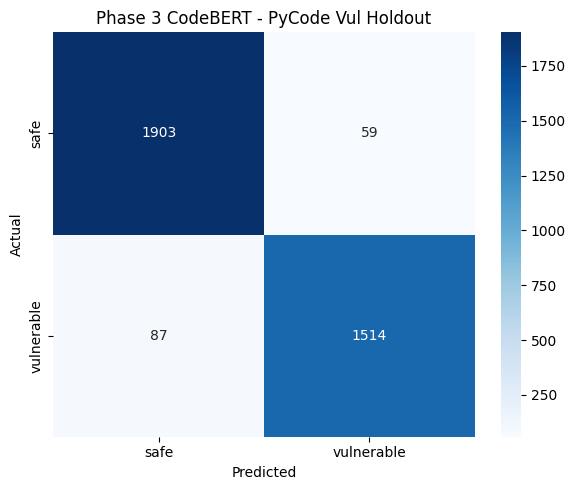

Block 9 complete.


In [11]:
# ── PHASE 3 BLOCK 9 ──────────────────────────────
# Title: Evaluate CodeBERT on Untouched Holdout
# Purpose: Final official Phase 3 binary result

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

print("Getting holdout predictions...")
test_pred_output = trainer.predict(test_dataset)

test_logits = test_pred_output.predictions
test_labels = test_pred_output.label_ids.astype(int)

test_probs = torch.softmax(
    torch.tensor(test_logits),
    dim=1
).numpy()[:, 1]

# Use threshold selected on validation set
test_preds = (test_probs >= best_threshold).astype(int)

test_accuracy = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds, zero_division=0)
test_recall = recall_score(test_labels, test_preds, zero_division=0)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)
test_auc = roc_auc_score(test_labels, test_probs)

print("Official CodeBERT Holdout Results")
print("---------------------------------")
print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

print("\nComparison")
print("----------")
phase1_f1 = 0.7220
phase2_f1 = 0.9505

print(f"Phase 1 Ensemble F1:       {phase1_f1:.4f}")
print(f"Phase 2 BiLSTM F1:         {phase2_f1:.4f}")
print(f"Phase 3 CodeBERT F1:       {test_f1:.4f}")

print(f"\nCodeBERT vs Phase 1 absolute improvement: {test_f1 - phase1_f1:.4f}")
print(f"CodeBERT vs Phase 2 absolute improvement: {test_f1 - phase2_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        test_preds,
        target_names=["safe", "vulnerable"],
        digits=4
    )
)

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["safe", "vulnerable"],
    yticklabels=["safe", "vulnerable"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Phase 3 CodeBERT - PyCode Vul Holdout")
plt.tight_layout()
plt.show()

print("Block 9 complete.")

Evaluating train split...



Train Results
-------------
Accuracy:  0.9906
Precision: 0.9911
Recall:    0.9878
F1:        0.9894
ROC-AUC:   0.9987

Validation Results
------------------
Threshold: 0.23
Accuracy:  0.9686
Precision: 0.9698
Recall:    0.9594
F1:        0.9646

Holdout Results
---------------
Accuracy:  0.9590
Precision: 0.9625
Recall:    0.9457
F1:        0.9540
ROC-AUC:   0.9889

Generalization Gaps
-------------------
Train - Val F1:     0.0248
Val - Holdout F1:   0.0106
Train - Holdout F1: 0.0354


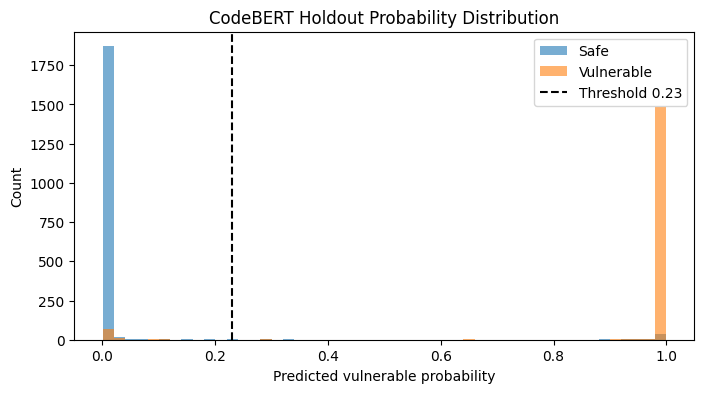


Holdout confusion matrix:
[[1903   59]
 [  87 1514]]

Block 10 complete.


In [12]:
# ── PHASE 3 BLOCK 10 ─────────────────────────────
# Title: Overfitting and Generalization Diagnostics
# Purpose: Compare train/val/holdout metrics and inspect prediction behavior

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating train split...")
train_pred_output = trainer.predict(train_dataset)

train_logits = train_pred_output.predictions
train_labels = train_pred_output.label_ids.astype(int)

train_probs = torch.softmax(
    torch.tensor(train_logits),
    dim=1
).numpy()[:, 1]

train_preds = (train_probs >= best_threshold).astype(int)

train_accuracy = accuracy_score(train_labels, train_preds)
train_precision = precision_score(train_labels, train_preds, zero_division=0)
train_recall = recall_score(train_labels, train_preds, zero_division=0)
train_f1 = f1_score(train_labels, train_preds, zero_division=0)
train_auc = roc_auc_score(train_labels, train_probs)

print("\nTrain Results")
print("-------------")
print(f"Accuracy:  {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1:        {train_f1:.4f}")
print(f"ROC-AUC:   {train_auc:.4f}")

print("\nValidation Results")
print("------------------")
print(f"Threshold: {best_threshold:.2f}")
print(f"Accuracy:  {best_metrics['accuracy']:.4f}")
print(f"Precision: {best_metrics['precision']:.4f}")
print(f"Recall:    {best_metrics['recall']:.4f}")
print(f"F1:        {best_metrics['f1']:.4f}")

print("\nHoldout Results")
print("---------------")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1:        {test_f1:.4f}")
print(f"ROC-AUC:   {test_auc:.4f}")

print("\nGeneralization Gaps")
print("-------------------")
print(f"Train - Val F1:     {train_f1 - best_metrics['f1']:.4f}")
print(f"Val - Holdout F1:   {best_metrics['f1'] - test_f1:.4f}")
print(f"Train - Holdout F1: {train_f1 - test_f1:.4f}")

# Probability distributions on holdout
plt.figure(figsize=(8, 4))
plt.hist(test_probs[test_labels == 0], bins=50, alpha=0.6, label="Safe")
plt.hist(test_probs[test_labels == 1], bins=50, alpha=0.6, label="Vulnerable")
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Threshold {best_threshold:.2f}")
plt.xlabel("Predicted vulnerable probability")
plt.ylabel("Count")
plt.title("CodeBERT Holdout Probability Distribution")
plt.legend()
plt.show()

print("\nHoldout confusion matrix:")
print(confusion_matrix(test_labels, test_preds))

print("\nBlock 10 complete.")

In [13]:
df = pd.read_excel(f'{PROJECT}/data/PyCode_Vul_train.xlsx')
print(df.columns.tolist())
print(df.head(3))

['__source_file', 'cve_ids', 'cwe_ids', 'file_path', 'label', 'patched_function_source', 'predicted_cwe_ids', 'repo', 'sha', 'vulnerable_function_source']
  __source_file  cve_ids  cwe_ids  \
0           NaN  UNKNOWN  UNKNOWN   
1           NaN  UNKNOWN  UNKNOWN   
2           NaN  UNKNOWN  UNKNOWN   

                                           file_path  label  \
0  tests/store/artifact/test_azure_blob_artifact_...      1   
1                               tests/test_config.py      1   
2                django/core/management/templates.py      1   

                             patched_function_source predicted_cwe_ids  \
0  def test_list_artifacts_empty(mock_client):\n ...           CWE-703   
1  def test_config_from_envvar_missing(monkeypatc...           CWE-703   
2  def handle(self, app_or_project, name, target=...            CWE-79   

            repo                                       sha  \
0  mlflow/mlflow  04708a9e52774e23e17bf73d6221be0758177a68   
1  pallets/flask  d4b6

In [14]:
df = pd.read_excel(f'{PROJECT}/data/PyCode_Vul_train.xlsx')

print("=== CWE COLUMN ANALYSIS ===")
print(f"\ncwe_ids known (not UNKNOWN): "
      f"{(df['cwe_ids'] != 'UNKNOWN').sum()}")
print(f"cwe_ids UNKNOWN: "
      f"{(df['cwe_ids'] == 'UNKNOWN').sum()}")

print(f"\npredicted_cwe_ids distribution:")
print(df['predicted_cwe_ids'].value_counts().head(20))

print(f"\nVulnerable rows only:")
vuln = df[df['label'] == 1]
print(f"Total vulnerable: {len(vuln)}")
print(f"predicted_cwe_ids distribution (vulnerable only):")
print(vuln['predicted_cwe_ids'].value_counts().head(20))

=== CWE COLUMN ANALYSIS ===

cwe_ids known (not UNKNOWN): 0
cwe_ids UNKNOWN: 14248

predicted_cwe_ids distribution:
predicted_cwe_ids
CWE-703             3903
CWE-Unknown         2181
CWE-259              447
CWE-89               438
UNKNOWN              351
CWE-79               277
CWE-330              182
CWE-327              167
CWE-605              151
CWE-78               134
CWE-94               101
CWE-20                88
CWE-22                78
CWE-259, CWE-703      66
CWE-502               65
CWE-94, CWE-330       38
CWE-295               22
CWE-327, CWE-330      17
CWE-22, CWE-78        17
CWE-89, CWE-703       17
Name: count, dtype: int64

Vulnerable rows only:
Total vulnerable: 6298
predicted_cwe_ids distribution (vulnerable only):
predicted_cwe_ids
CWE-703             3903
CWE-259              447
CWE-89               438
CWE-79               277
CWE-330              182
CWE-327              167
CWE-605              151
CWE-78               134
CWE-94               101
C

In [15]:
# ── PHASE 3 BLOCK 11 ─────────────────────────────
# Title: Save Final CodeBERT Binary Artifacts
# Purpose: Save model, tokenizer, config, metrics, and training details

import json
import os

CODEBERT_BINARY_DIR = f"{PROJECT}/models/saved/codebert_binary"
os.makedirs(CODEBERT_BINARY_DIR, exist_ok=True)

# Save best model and tokenizer
trainer.save_model(CODEBERT_BINARY_DIR)
tokenizer.save_pretrained(CODEBERT_BINARY_DIR)

phase3_config = {
    "phase": "Phase 3",
    "model_name": "microsoft/codebert-base",
    "task": "binary_vulnerability_detection",
    "architecture": "CodeBERT / RobertaForSequenceClassification",
    "num_labels": 2,
    "labels": {
        "0": "safe",
        "1": "vulnerable"
    },
    "max_length": MAX_LEN,
    "truncation_strategy": "head_tail",
    "threshold": float(best_threshold),
    "threshold_selected_on": "validation_f1",
    "training_data": "PyCode Vul cleaned train split",
    "holdout_data": "PyCode Vul untouched test split",
    "train_size": int(len(train_split)),
    "validation_size": int(len(val_split)),
    "holdout_size": int(len(test_df)),
    "learning_rate": 2e-5,
    "epochs_requested": 4,
    "best_validation_f1": float(best_metrics["f1"]),
    "class_weights": {
        "safe": float(class_weights[0].item()),
        "vulnerable": float(class_weights[1].item())
    }
}

phase3_metrics = {
    "train": {
        "accuracy": float(train_accuracy),
        "precision": float(train_precision),
        "recall": float(train_recall),
        "f1": float(train_f1),
        "roc_auc": float(train_auc)
    },
    "validation": {
        "threshold": float(best_threshold),
        "accuracy": float(best_metrics["accuracy"]),
        "precision": float(best_metrics["precision"]),
        "recall": float(best_metrics["recall"]),
        "f1": float(best_metrics["f1"])
    },
    "holdout": {
        "threshold": float(best_threshold),
        "accuracy": float(test_accuracy),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1": float(test_f1),
        "roc_auc": float(test_auc),
        "confusion_matrix": {
            "true_safe_pred_safe": int(cm[0][0]),
            "true_safe_pred_vulnerable": int(cm[0][1]),
            "true_vulnerable_pred_safe": int(cm[1][0]),
            "true_vulnerable_pred_vulnerable": int(cm[1][1])
        }
    },
    "comparison": {
        "phase1_ensemble_f1": 0.7220,
        "phase2_bilstm_f1": 0.9505,
        "phase3_codebert_f1": float(test_f1),
        "codebert_vs_phase1_absolute_f1": float(test_f1 - 0.7220),
        "codebert_vs_phase2_absolute_f1": float(test_f1 - 0.9505)
    },
    "generalization_gaps": {
        "train_minus_validation_f1": float(train_f1 - best_metrics["f1"]),
        "validation_minus_holdout_f1": float(best_metrics["f1"] - test_f1),
        "train_minus_holdout_f1": float(train_f1 - test_f1)
    }
}

split_summary = {
    "removed_train_test_overlap": 92,
    "removed_duplicate_train_code": 41,
    "train_distribution": {
        str(k): int(v)
        for k, v in train_split["label"].value_counts().sort_index().items()
    },
    "validation_distribution": {
        str(k): int(v)
        for k, v in val_split["label"].value_counts().sort_index().items()
    },
    "holdout_distribution": {
        str(k): int(v)
        for k, v in test_df["label"].value_counts().sort_index().items()
    }
}

with open(f"{CODEBERT_BINARY_DIR}/phase3_codebert_binary_config.json", "w") as f:
    json.dump(phase3_config, f, indent=2)

with open(f"{CODEBERT_BINARY_DIR}/phase3_codebert_binary_metrics.json", "w") as f:
    json.dump(phase3_metrics, f, indent=2)

with open(f"{CODEBERT_BINARY_DIR}/phase3_codebert_binary_split_summary.json", "w") as f:
    json.dump(split_summary, f, indent=2)

print("Saved CodeBERT binary model and artifacts to:")
print(CODEBERT_BINARY_DIR)

print("\nFiles:")
for file in sorted(os.listdir(CODEBERT_BINARY_DIR)):
    print(" ", file)

print("\nBlock 11 complete.")

Saved CodeBERT binary model and artifacts to:
/content/drive/MyDrive/securescope-ai/models/saved/codebert_binary

Files:
  checkpoint-2236
  checkpoint-2980
  config.json
  merges.txt
  model.safetensors
  phase3_codebert_binary_config.json
  phase3_codebert_binary_metrics.json
  phase3_codebert_binary_split_summary.json
  special_tokens_map.json
  tokenizer.json
  tokenizer_config.json
  training_args.bin
  vocab.json

Block 11 complete.


In [25]:
CODEBERT_BINARY_DIR = f"{PROJECT}/models/saved/codebert_binary"

trainer.save_model(CODEBERT_BINARY_DIR)
tokenizer.save_pretrained(CODEBERT_BINARY_DIR)

print("Saved CodeBERT model to:", CODEBERT_BINARY_DIR)

Saved CodeBERT model to: /content/drive/MyDrive/securescope-ai/models/saved/codebert_binary
